In [6]:
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define paths
BASE_DIR = Path(r"D:\Ali Garrab\day_2")
INPUT_PATH = BASE_DIR / "input" / "objects2.jpg"
OUTPUT_DIR = BASE_DIR / "output"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Working directory configured: {BASE_DIR}")

Working directory configured: D:\Ali Garrab\day_2


In [7]:
def load_and_inspect(filepath):
    """Loads image and prints metadata."""
    img = cv2.imread(str(filepath))
    if img is None:
        raise FileNotFoundError(f"Could not load image at '{filepath}'")

    h, w, c = img.shape
    print("--- Image Information ---")
    print(
        f"Width: {w} px | Height: {h} px | Channels: {c} | Data Type: {img.dtype}"
    )
    return img


def preprocess_image(image, ksize=5):
    """Applies Gaussian Blur for noise suppression."""
    return cv2.GaussianBlur(image, (ksize, ksize), 0)


def segment_hsv(
    hsv_img, lower_bound=(0, 30, 30), upper_bound=(180, 255, 255)
):
    """Thresholds HSV image to create a binary mask."""
    lower = np.array(lower_bound, dtype=np.uint8)
    upper = np.array(upper_bound, dtype=np.uint8)
    return cv2.inRange(hsv_img, lower, upper)


def clean_mask(mask, ksize=5):
    """Applies Morphological Opening (remove noise) and Closing (fill holes)."""
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    return cleaned


def classify_shape(contour):
    """Determines geometric shape using polygon approximation and circularity."""
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.04 * peri, True)
    vertices = len(approx)

    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = float(w) / h if h != 0 else 0

    if vertices == 3:
        return "Triangle"
    elif vertices == 4:
        if 0.92 <= aspect_ratio <= 1.08:
            return "Square"
        return "Rectangle"
    elif vertices > 4:
        area = cv2.contourArea(contour)
        circularity = (4 * np.pi * area) / (peri**2) if peri > 0 else 0
        if circularity > 0.65:
            return "Circle"
        return "Unknown"
    return "Unknown"


def classify_color(hsv_img, contour):
    """Extracts mean Hue/Saturation values inside the object region."""
    mask = np.zeros(hsv_img.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, -1)

    mean_val = cv2.mean(hsv_img, mask=mask)
    hue, sat = mean_val[0], mean_val[1]

    if sat < 30:
        return "Other"

    if hue < 10 or hue >= 160:
        return "Red"
    elif 10 <= hue < 25:
        return "Orange"
    elif 25 <= hue < 35:
        return "Yellow"
    elif 35 <= hue < 85:
        return "Green"
    elif 85 <= hue < 130:
        return "Blue"
    return "Other"


def extract_features(contours, hsv_img):
    """Calculates geometric properties and centroids using spatial moments."""
    features = []
    for idx, cnt in enumerate(contours, start=1):
        area = cv2.contourArea(cnt)
        peri = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = round(float(w) / h, 2) if h != 0 else 0.0

        # Calculate centroid via contour spatial moments
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = x + w // 2, y + h // 2

        shape = classify_shape(cnt)
        color = classify_color(hsv_img, cnt)

        features.append(
            {
                "id": idx,
                "contour": cnt,
                "color": color,
                "shape": shape,
                "area": round(area, 2),
                "perimeter": round(peri, 2),
                "x": x,
                "y": y,
                "width": w,
                "height": h,
                "cx": cx,
                "cy": cy,
                "aspect_ratio": aspect_ratio,
            }
        )
    return features


def draw_annotations(image, features):
    """Overlays contours, bounding boxes, centroids, and labels."""
    annotated = image.copy()
    for obj in features:
        cnt = obj["contour"]
        x, y, w, h = obj["x"], obj["y"], obj["width"], obj["height"]
        cx, cy = obj["cx"], obj["cy"]

        # Contour (Green) & Bounding Box (Blue)
        cv2.drawContours(annotated, [cnt], -1, (0, 255, 0), 2)
        cv2.rectangle(annotated, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # Centroid (Red)
        cv2.circle(annotated, (cx, cy), 5, (0, 0, 255), -1)

        # Object Label
        label = f"#{obj['id']} {obj['color']} {obj['shape']}"
        cv2.putText(
            annotated,
            label,
            (x, max(y - 8, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 0, 0),
            2,
        )
        cv2.putText(
            annotated,
            label,
            (x, max(y - 8, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
        )

    return annotated

--- Image Information ---
Width: 576 px | Height: 577 px | Channels: 3 | Data Type: uint8


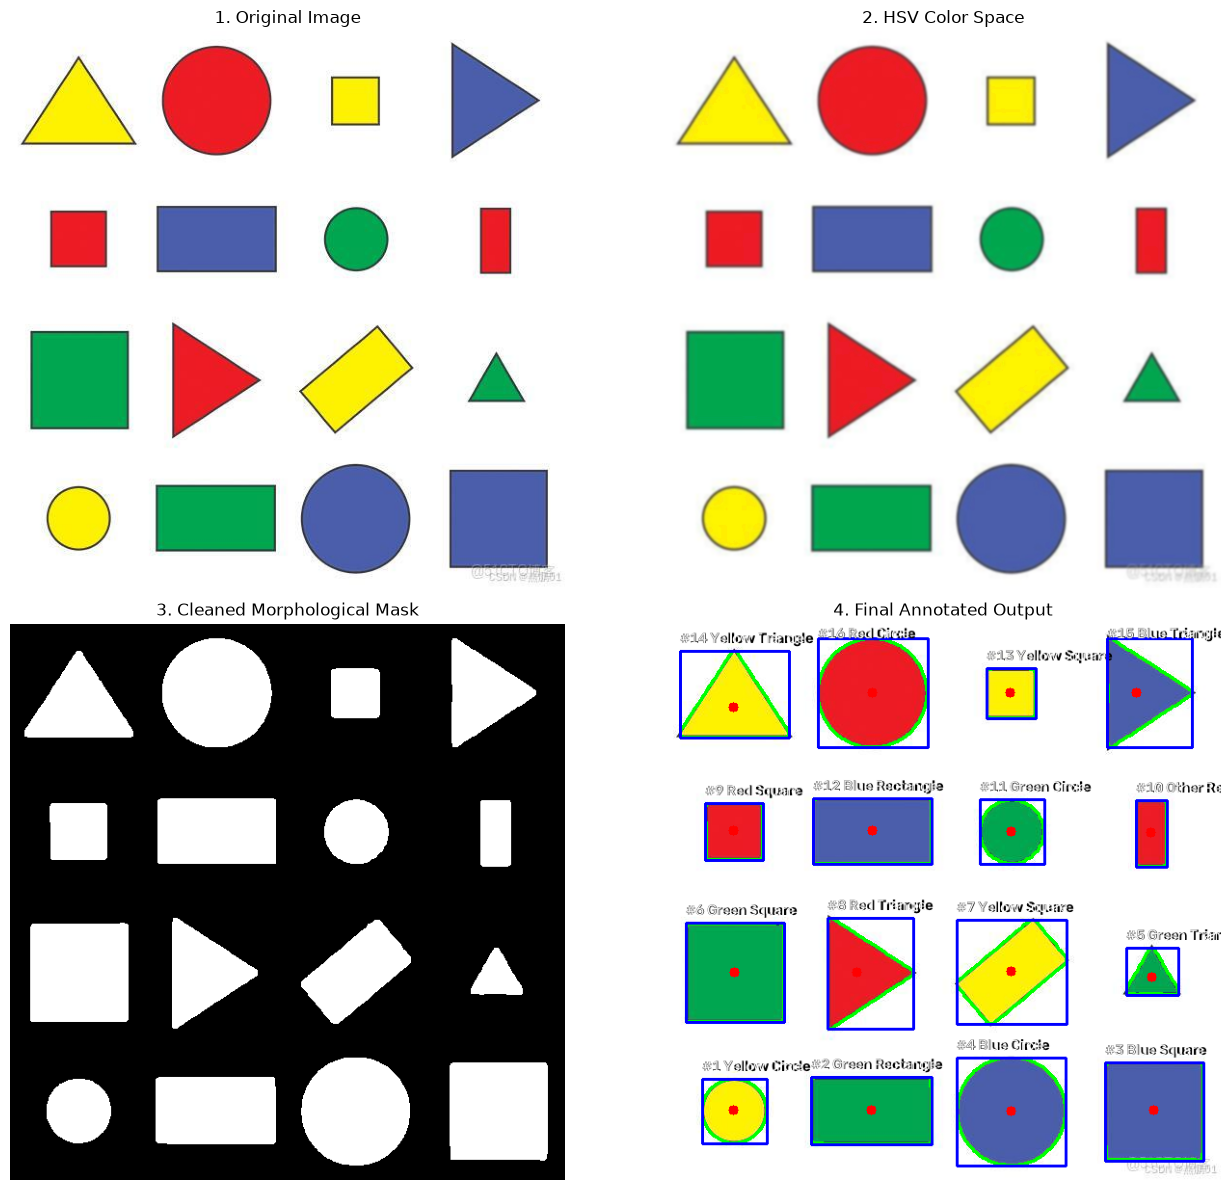

In [8]:
# 1. Load and Preprocess
image = load_and_inspect(INPUT_PATH)
blurred = preprocess_image(image, ksize=5)

# 2. Color Space Conversion & Segmentation
hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
raw_mask = segment_hsv(
    hsv, lower_bound=(0, 30, 30), upper_bound=(180, 255, 255)
)
cleaned_mask = clean_mask(raw_mask, ksize=5)

# 3. Contour Detection & Feature Extraction
contours, _ = cv2.findContours(
    cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
valid_contours = [c for c in contours if cv2.contourArea(c) >= 500]
features = extract_features(valid_contours, hsv)

# 4. Generate Annotated Display Image
annotated_img = draw_annotations(image, features)

# 5. Save Outputs
cv2.imwrite(str(OUTPUT_DIR / "mask.jpg"), cleaned_mask)
cv2.imwrite(str(OUTPUT_DIR / "annotated.jpg"), annotated_img)

# Convert BGR to RGB for inline Matplotlib rendering
orig_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Inline Display 1: Visual Pipeline Comparison (2x2 Grid)
plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
plt.imshow(orig_rgb)
plt.title("1. Original Image", fontsize=12)
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("2. HSV Color Space", fontsize=12)
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cleaned_mask, cmap="gray")
plt.title("3. Cleaned Morphological Mask", fontsize=12)
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(annotated_rgb)
plt.title("4. Final Annotated Output", fontsize=12)
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Create DataFrame excluding contour array object for tabular display
df_features = pd.DataFrame(features).drop(columns=["contour"])

# Export to CSV
csv_path = OUTPUT_DIR / "objects.csv"
df_features.to_csv(csv_path, index=False)
print(f"Saved CSV Report to: {csv_path}\n")

# Display formatted table inline
print("--- Extracted Object Feature Report ---")
df_features

Saved CSV Report to: D:\Ali Garrab\day_2\output\objects.csv

--- Extracted Object Feature Report ---


,id,color,shape,area,perimeter,x,y,width,height,cx,cy,aspect_ratio
0,1,Yellow,Circle,3455.0,220.65,38,472,67,67,70,504,1.00
1,2,Green,Rectangle,8527.5,380.73,151,470,125,70,213,504,1.79
2,3,Blue,Square,10078.5,398.73,456,455,102,102,506,504,1.00
3,4,Blue,Circle,9874.0,372.19,302,450,113,112,358,505,1.01
4,5,Green,Triangle,1483.5,172.95,478,336,54,49,504,366,1.10
5,6,Green,Square,10200.0,401.31,21,310,102,103,71,361,0.99
6,7,Yellow,Square,6103.5,330.46,302,307,114,108,358,360,1.06
7,8,Red,Triangle,5463.5,338.98,168,305,89,115,198,361,0.77
8,9,Red,Square,3376.0,229.31,41,186,60,59,70,214,1.02
9,10,Other,Rectangle,2101.0,194.49,488,183,32,69,503,216,0.46


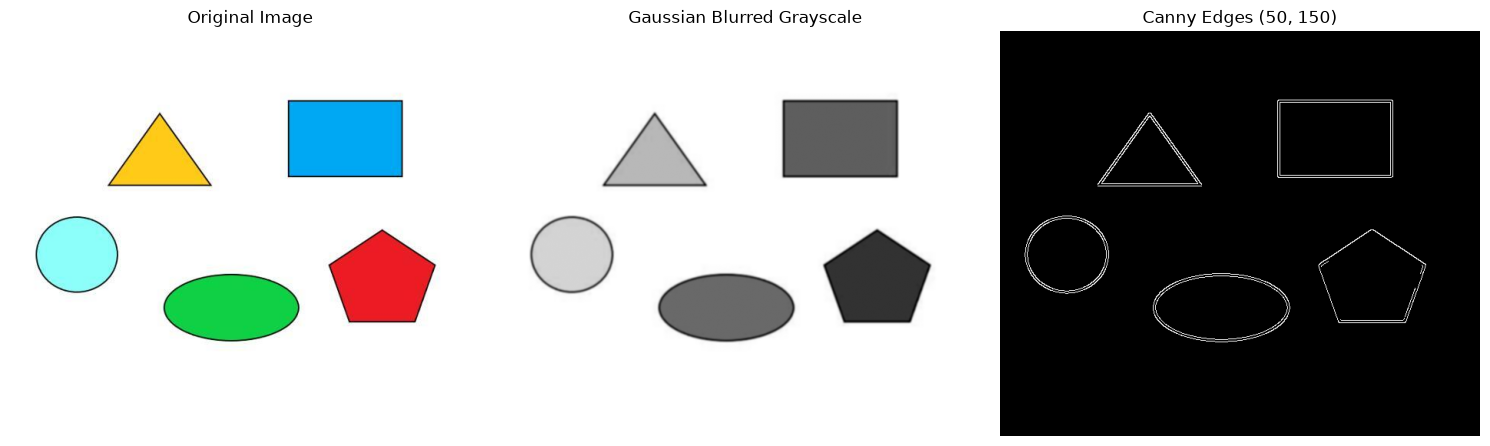

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Load image
image_path = r"D:\Ali Garrab\day_2\input\objects.jpg"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not load image from '{image_path}'")

# 2. Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Apply Gaussian Blur to reduce noise before edge detection
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 4. Apply Canny Edge Detection
# Threshold parameters:
# - Below 50: discarded as noise
# - Above 150: considered strong edge pixels
# - Between 50 and 150: kept if connected to strong edge pixels
threshold1 = 50
threshold2 = 150
canny_edges = cv2.Canny(blurred, threshold1, threshold2)

# 5. Save output edge image
cv2.imwrite(r"D:\Ali Garrab\day_2\output\canny_edges.jpg", canny_edges)

# 6. Display results inline
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canny_edges, cmap="gray")
plt.title(f"Canny Edges ({threshold1}, {threshold2})")
plt.axis("off")

plt.tight_layout()
plt.show()

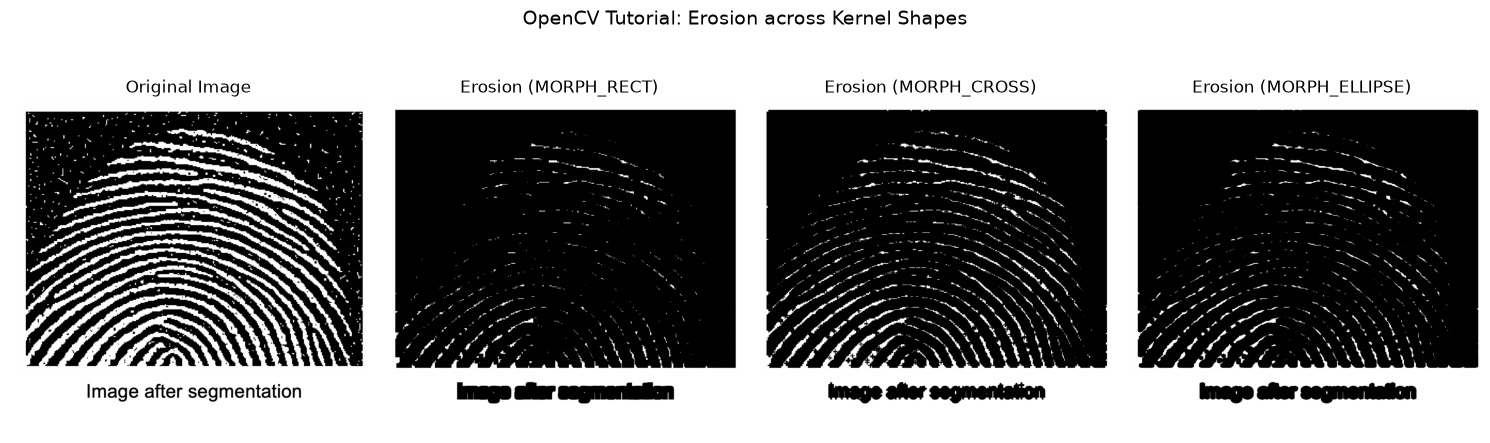

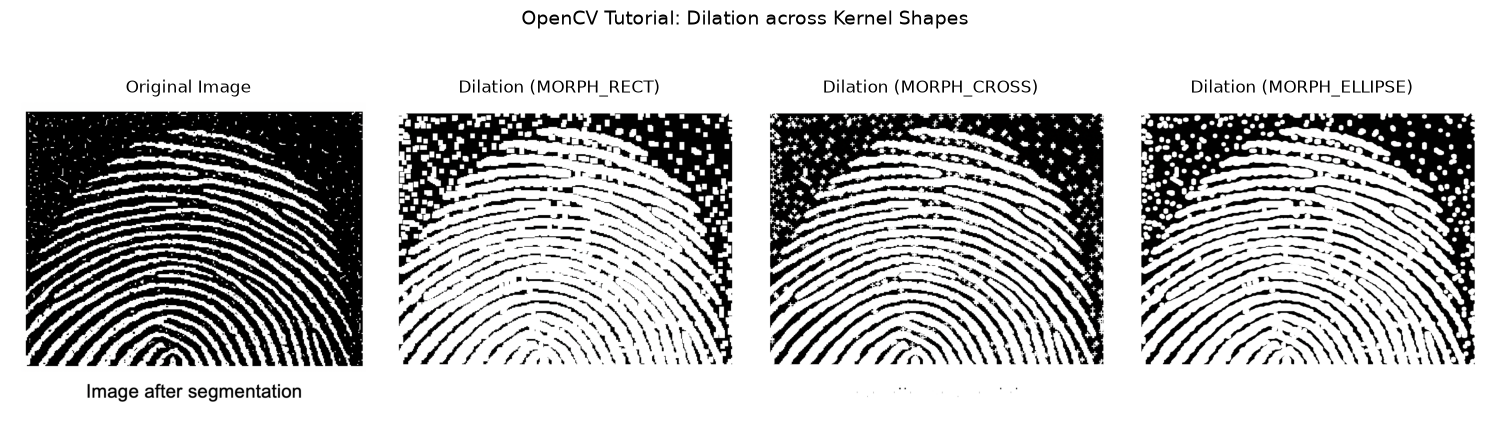

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Read input image
image_path = r"D:\Ali Garrab\day_2\input\morphology_images1.png"
src = cv2.imread(image_path)

if src is None:
    raise FileNotFoundError(f"Could not load image at '{image_path}'")

# 2. Convert to RGB for visualization
src_rgb = cv2.cvtColor(src, cv2.COLOR_BGR2RGB)

# 3. Define Kernel Size (Tutorial formula: 2 * size + 1 to guarantee odd dimensions)
kernel_size = 5
ksize = (2 * kernel_size + 1, 2 * kernel_size + 1)

# 4. Create Structuring Elements (as specified in the OpenCV tutorial)
rect_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize)
cross_kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, ksize)
ellipse_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, ksize)

# 5. Apply Erosion with the three kernel types
eroded_rect = cv2.erode(src, rect_kernel, iterations=1)
eroded_cross = cv2.erode(src, cross_kernel, iterations=1)
eroded_ellipse = cv2.erode(src, ellipse_kernel, iterations=1)

# 6. Apply Dilation with the three kernel types
dilated_rect = cv2.dilate(src, rect_kernel, iterations=1)
dilated_cross = cv2.dilate(src, cross_kernel, iterations=1)
dilated_ellipse = cv2.dilate(src, ellipse_kernel, iterations=1)

# --- DISPLAY 1: EROSION COMPARISON ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(src_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(eroded_rect, cv2.COLOR_BGR2RGB))
plt.title("Erosion (MORPH_RECT)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(eroded_cross, cv2.COLOR_BGR2RGB))
plt.title("Erosion (MORPH_CROSS)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(eroded_ellipse, cv2.COLOR_BGR2RGB))
plt.title("Erosion (MORPH_ELLIPSE)")
plt.axis("off")

plt.suptitle("OpenCV Tutorial: Erosion across Kernel Shapes", fontsize=14)
plt.tight_layout()
plt.show()

# --- DISPLAY 2: DILATION COMPARISON ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(src_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(dilated_rect, cv2.COLOR_BGR2RGB))
plt.title("Dilation (MORPH_RECT)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(dilated_cross, cv2.COLOR_BGR2RGB))
plt.title("Dilation (MORPH_CROSS)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(dilated_ellipse, cv2.COLOR_BGR2RGB))
plt.title("Dilation (MORPH_ELLIPSE)")
plt.axis("off")

plt.suptitle("OpenCV Tutorial: Dilation across Kernel Shapes", fontsize=14)
plt.tight_layout()
plt.show()

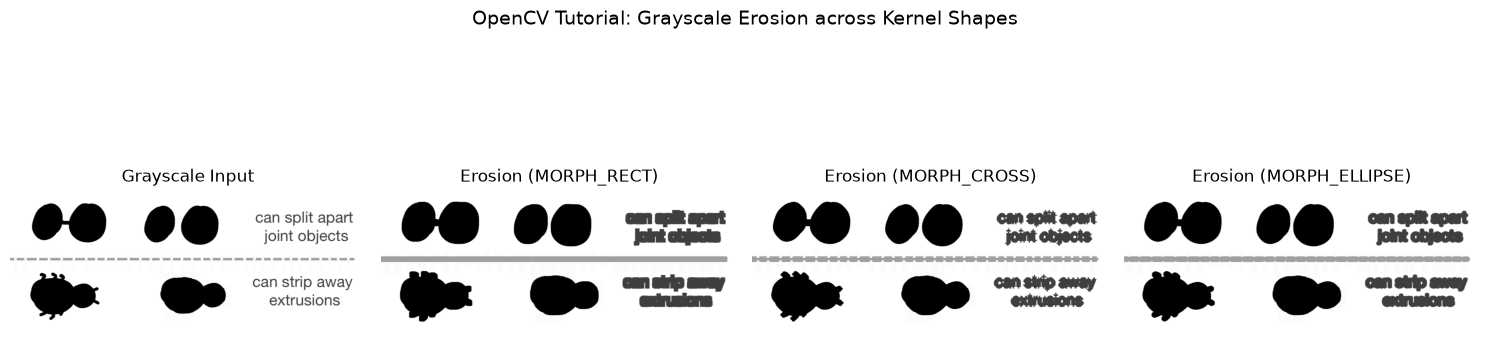

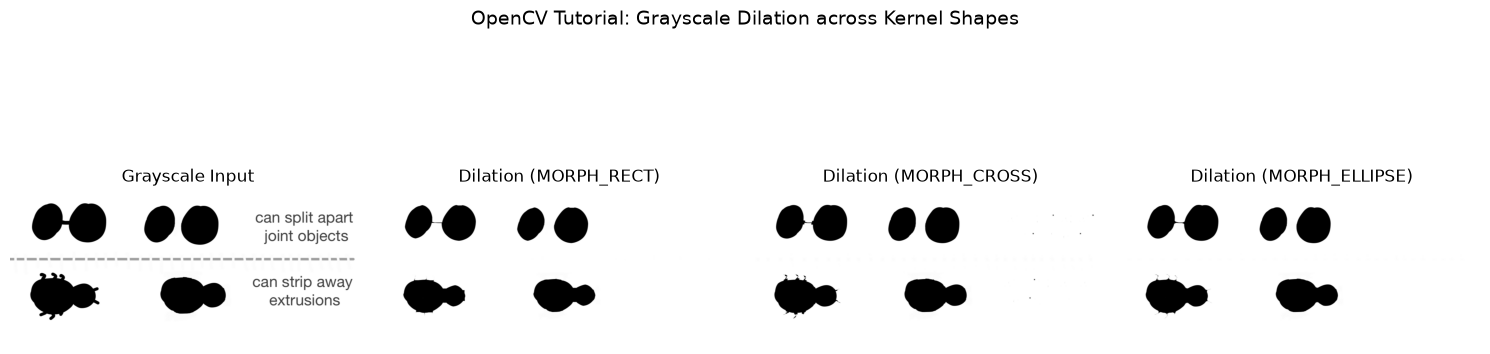

In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Read input image
image_path = r"D:\Ali Garrab\day_2\input\morphology3.png"
src = cv2.imread(image_path)

if src is None:
    raise FileNotFoundError(f"Could not load image at '{image_path}'")

# 2. Convert to Grayscale FIRST
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

# 3. Define Kernel Size (Tutorial formula: 2 * size + 1 to guarantee odd dimensions)
kernel_size = 5
ksize = (2 * kernel_size + 1, 2 * kernel_size + 1)

# 4. Create Structuring Elements
rect_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize)
cross_kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, ksize)
ellipse_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, ksize)

# 5. Apply Erosion on Grayscale image
eroded_rect = cv2.erode(gray, rect_kernel, iterations=1)
eroded_cross = cv2.erode(gray, cross_kernel, iterations=1)
eroded_ellipse = cv2.erode(gray, ellipse_kernel, iterations=1)

# 6. Apply Dilation on Grayscale image
dilated_rect = cv2.dilate(gray, rect_kernel, iterations=1)
dilated_cross = cv2.dilate(gray, cross_kernel, iterations=1)
dilated_ellipse = cv2.dilate(gray, ellipse_kernel, iterations=1)

# --- DISPLAY 1: GRAYSCALE EROSION COMPARISON ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(eroded_rect, cmap="gray")
plt.title("Erosion (MORPH_RECT)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(eroded_cross, cmap="gray")
plt.title("Erosion (MORPH_CROSS)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(eroded_ellipse, cmap="gray")
plt.title("Erosion (MORPH_ELLIPSE)")
plt.axis("off")

plt.suptitle("OpenCV Tutorial: Grayscale Erosion across Kernel Shapes", fontsize=14)
plt.tight_layout()
plt.show()

# --- DISPLAY 2: GRAYSCALE DILATION COMPARISON ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(dilated_rect, cmap="gray")
plt.title("Dilation (MORPH_RECT)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(dilated_cross, cmap="gray")
plt.title("Dilation (MORPH_CROSS)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(dilated_ellipse, cmap="gray")
plt.title("Dilation (MORPH_ELLIPSE)")
plt.axis("off")

plt.suptitle("OpenCV Tutorial: Grayscale Dilation across Kernel Shapes", fontsize=14)
plt.tight_layout()
plt.show()

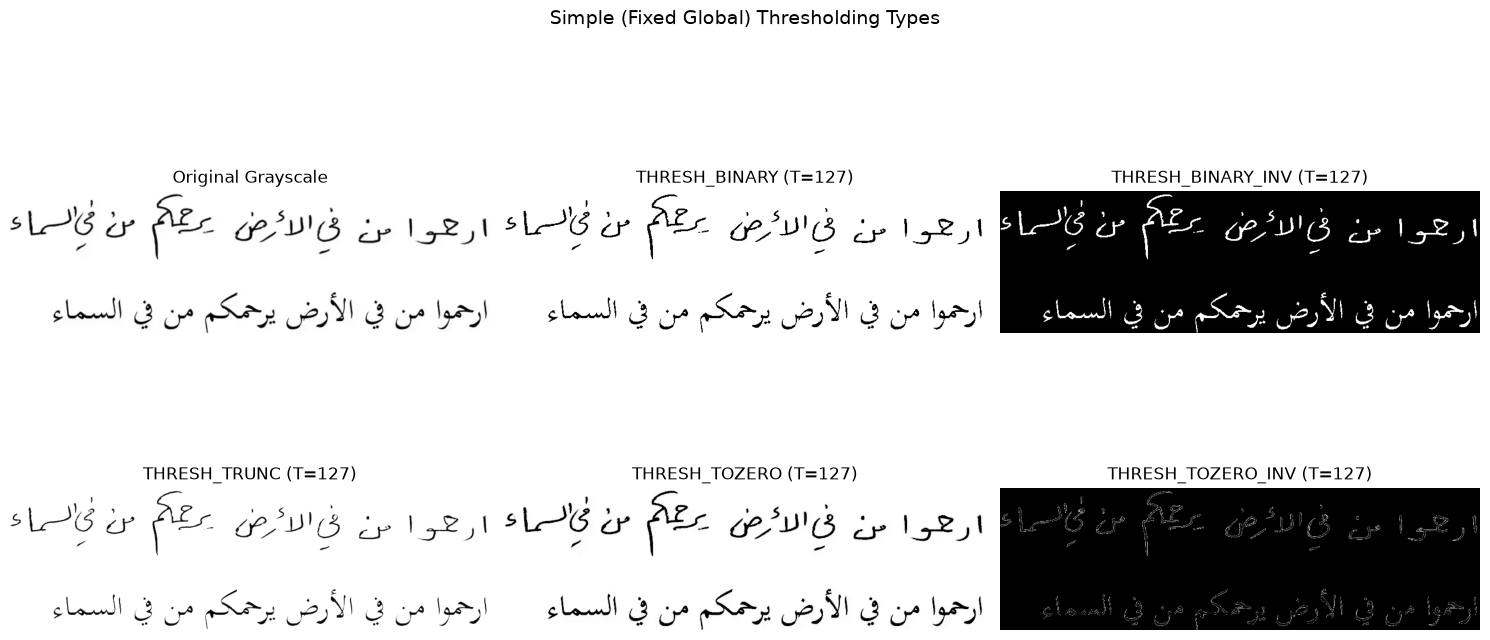

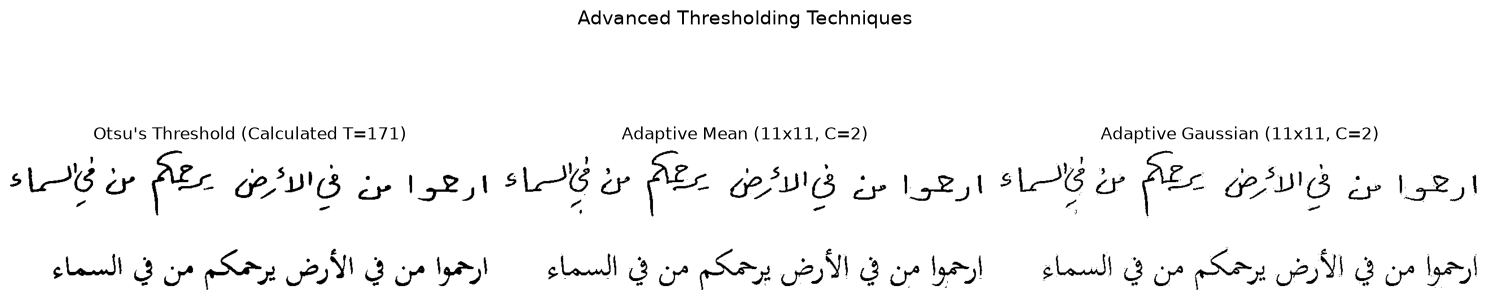

In [4]:
import cv2
import matplotlib.pyplot as plt

# 1. Load image in grayscale
image_path = r"D:\Ali Garrab\day_2\input\handwrittenArabic.webp"
gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if gray is None:
    raise FileNotFoundError(f"Could not load image at '{image_path}'")

# --- 1. SIMPLE THRESHOLDING (Fixed T = 127) ---
T = 127
_, thresh_binary = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)
_, thresh_binary_inv = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY_INV)
_, thresh_trunc = cv2.threshold(gray, T, 255, cv2.THRESH_TRUNC)
_, thresh_tozero = cv2.threshold(gray, T, 255, cv2.THRESH_TOZERO)
_, thresh_tozero_inv = cv2.threshold(gray, T, 255, cv2.THRESH_TOZERO_INV)

# --- 2. OTSU'S AUTOMATED THRESHOLDING ---
# Pre-blurring recommended to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
otsu_val, thresh_otsu = cv2.threshold(
    blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# --- 3. ADAPTIVE THRESHOLDING ---
adaptive_mean = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2
)
adaptive_gauss = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

# --- DISPLAY 1: SIMPLE THRESHOLD TYPES ---
plt.figure(figsize=(15, 8))
simple_titles = [
    "Original Grayscale",
    f"THRESH_BINARY (T={T})",
    f"THRESH_BINARY_INV (T={T})",
    f"THRESH_TRUNC (T={T})",
    f"THRESH_TOZERO (T={T})",
    f"THRESH_TOZERO_INV (T={T})",
]
simple_imgs = [
    gray,
    thresh_binary,
    thresh_binary_inv,
    thresh_trunc,
    thresh_tozero,
    thresh_tozero_inv,
]

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(simple_imgs[i], cmap="gray")
    plt.title(simple_titles[i])
    plt.axis("off")

plt.suptitle("Simple (Fixed Global) Thresholding Types", fontsize=14)
plt.tight_layout()
plt.show()

# --- DISPLAY 2: OTSU & ADAPTIVE THRESHOLDING ---
plt.figure(figsize=(15, 4))
adv_titles = [
    f"Otsu's Threshold (Calculated T={int(otsu_val)})",
    "Adaptive Mean (11x11, C=2)",
    "Adaptive Gaussian (11x11, C=2)",
]
adv_imgs = [thresh_otsu, adaptive_mean, adaptive_gauss]

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(adv_imgs[i], cmap="gray")
    plt.title(adv_titles[i])
    plt.axis("off")

plt.suptitle("Advanced Thresholding Techniques", fontsize=14)
plt.tight_layout()
plt.show()

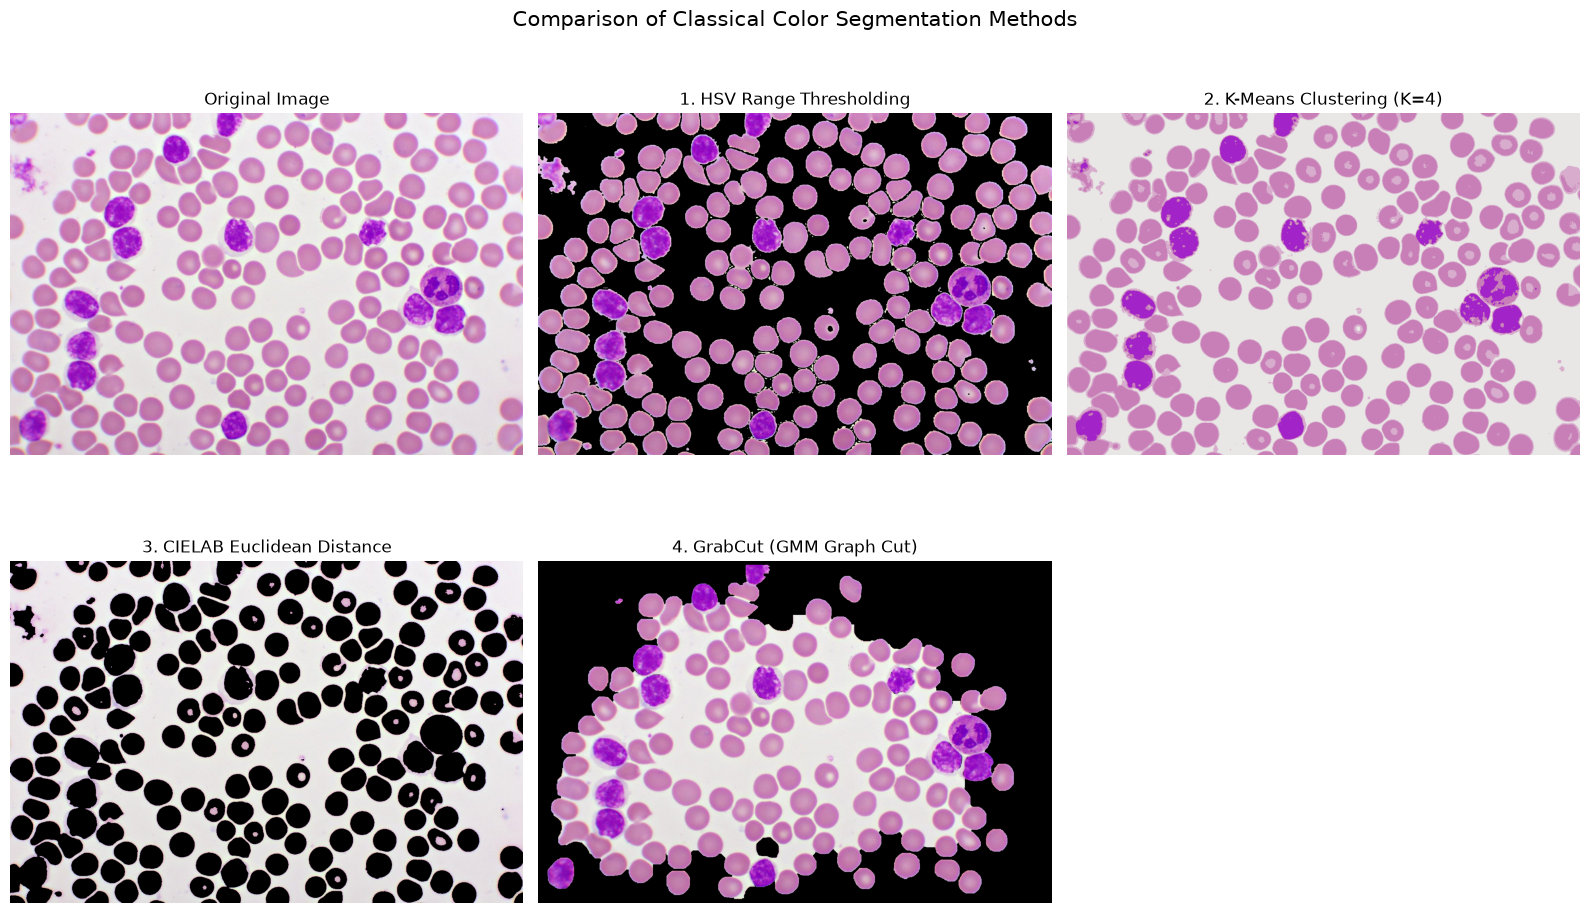

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Image
image_path = r"D:\Ali Garrab\day_2\input\bloodcells.jpeg"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not load image at '{image_path}'")

h, w, c = image.shape
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ==========================================================
# METHOD 1: HSV Color Range Thresholding
# ==========================================================
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# Target non-background saturated objects (Saturation >= 30, Value >= 30)
lower_hsv = np.array([0, 30, 30])
upper_hsv = np.array([180, 255, 255])
hsv_mask = cv2.inRange(hsv, lower_hsv, upper_hsv)
res_hsv = cv2.bitwise_and(image_rgb, image_rgb, mask=hsv_mask)

# ==========================================================
# METHOD 2: K-Means Color Clustering (K = 4)
# ==========================================================
pixel_values = image_rgb.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
K = 4  # Number of dominant color clusters
_, labels, centers = cv2.kmeans(
    pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS
)

centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
res_kmeans = segmented_data.reshape((image_rgb.shape))

# ==========================================================
# METHOD 3: CIELAB Color Distance Thresholding
# ==========================================================
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
# Define target color in Lab space (e.g., green object reference: L=120, a=80, b=160)
# Measure Euclidean distance from image center pixel as seed target
center_seed_color = lab[h // 2, w // 2].astype(np.float32)
color_diff = lab.astype(np.float32) - center_seed_color
euclidean_dist = np.sqrt(np.sum(color_diff**2, axis=2))

# Keep pixels within distance threshold
dist_mask = np.where(euclidean_dist < 60, 255, 0).astype(np.uint8)
res_lab = cv2.bitwise_and(image_rgb, image_rgb, mask=dist_mask)

# ==========================================================
# METHOD 4: GrabCut Segmentation (GMM Graph Cut)
# ==========================================================
gc_mask = np.zeros((h, w), np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Define bounding box surrounding target area (padding 10px from edges)
rect = (10, 10, w - 20, h - 20)
cv2.grabCut(
    image, gc_mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT
)

# Pixels marked as sure/probable foreground (1 or 3) are kept
gc_mask_binary = np.where((gc_mask == 1) | (gc_mask == 3), 1, 0).astype('uint8')
res_grabcut = image_rgb * gc_mask_binary[:, :, np.newaxis]

# ==========================================================
# VISUAL COMPARISON DISPLAY
# ==========================================================
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image", fontsize=12)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(res_hsv)
plt.title("1. HSV Range Thresholding", fontsize=12)
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(res_kmeans)
plt.title(f"2. K-Means Clustering (K={K})", fontsize=12)
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(res_lab)
plt.title("3. CIELAB Euclidean Distance", fontsize=12)
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(res_grabcut)
plt.title("4. GrabCut (GMM Graph Cut)", fontsize=12)
plt.axis("off")

plt.suptitle(
    "Comparison of Classical Color Segmentation Methods", fontsize=15
)
plt.tight_layout()
plt.show()

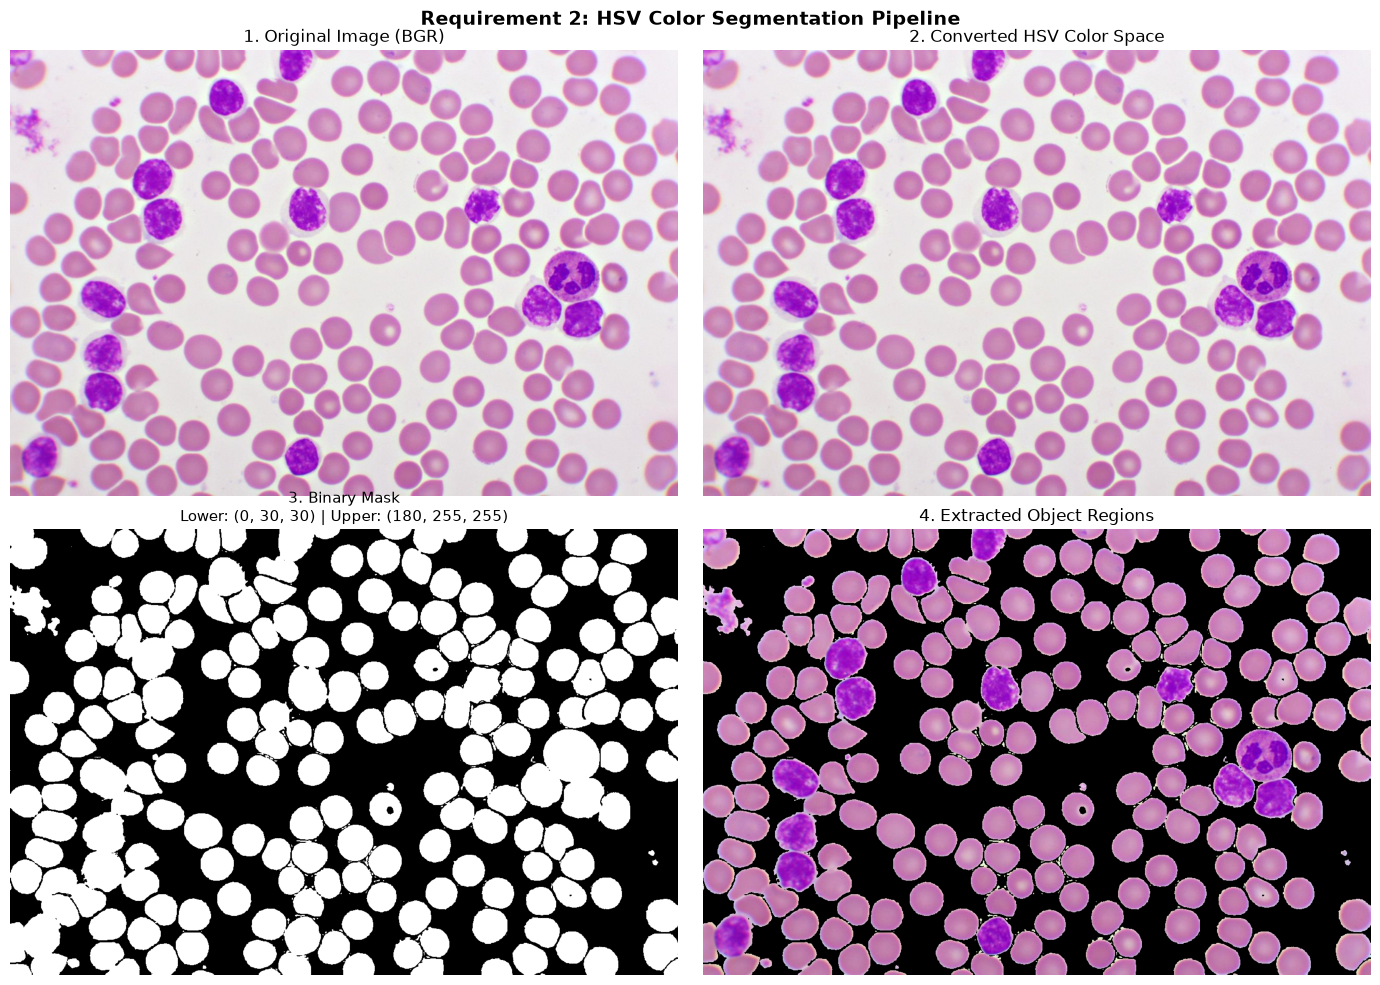

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# CONFIGURATION PARAMETERS (Configurable & Isolated)
# ==========================================================
# Input image path
IMAGE_PATH = r"D:\Ali Garrab\day_2\input\bloodcells.jpeg"

# HSV Ranges: Lower and Upper bounds
# Hue: 0-180, Saturation: 0-255, Value: 0-255
# Adjust these bounds to isolate target colors (e.g., non-background objects)
HSV_CONFIG = {
    "lower_bound": (0, 30, 30),  # Filters out low-saturation background noise
    "upper_bound": (180, 255, 255),  # Captures full hue spectrum
}


# ==========================================================
# COLOR SEGMENTATION FUNCTION
# ==========================================================
def segment_by_hsv(image, lower_hsv, upper_hsv):
    """Converts image from BGR to HSV, applies thresholding to generate a binary mask,

    and extracts target object regions.
    """
    # 1. Convert BGR -> HSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # 2. Define upper and lower bounds as NumPy arrays
    lower = np.array(lower_hsv, dtype=np.uint8)
    upper = np.array(upper_hsv, dtype=np.uint8)

    # 3. Generate Binary Mask (255 for target object pixels, 0 for background)
    binary_mask = cv2.inRange(hsv_image, lower, upper)

    # 4. Extract Object Regions using bitwise AND operation
    extracted_objects = cv2.bitwise_and(image, image, mask=binary_mask)

    return hsv_image, binary_mask, extracted_objects


# ==========================================================
# EXECUTION & VISUALIZATION
# ==========================================================
# Load image
src_image = cv2.imread(IMAGE_PATH)

if src_image is None:
    raise FileNotFoundError(f"Error: Could not load image from '{IMAGE_PATH}'")

# Execute segmentation using isolated configuration parameters
hsv_img, mask, segmented_objects = segment_by_hsv(
    src_image, HSV_CONFIG["lower_bound"], HSV_CONFIG["upper_bound"]
)

# Convert BGR images to RGB for Matplotlib inline display
orig_rgb = cv2.cvtColor(src_image, cv2.COLOR_BGR2RGB)
hsv_rgb = cv2.cvtColor(hsv_img, cv2.COLOR_HSV2RGB)
extracted_rgb = cv2.cvtColor(segmented_objects, cv2.COLOR_BGR2RGB)

# Display 2x2 comparison grid
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(orig_rgb)
plt.title("1. Original Image (BGR)", fontsize=12)
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(hsv_rgb)
plt.title("2. Converted HSV Color Space", fontsize=12)
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(mask, cmap="gray")
plt.title(
    f"3. Binary Mask\nLower: {HSV_CONFIG['lower_bound']} | Upper: {HSV_CONFIG['upper_bound']}",
    fontsize=11,
)
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(extracted_rgb)
plt.title("4. Extracted Object Regions", fontsize=12)
plt.axis("off")

plt.suptitle(
    "Requirement 2: HSV Color Segmentation Pipeline",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

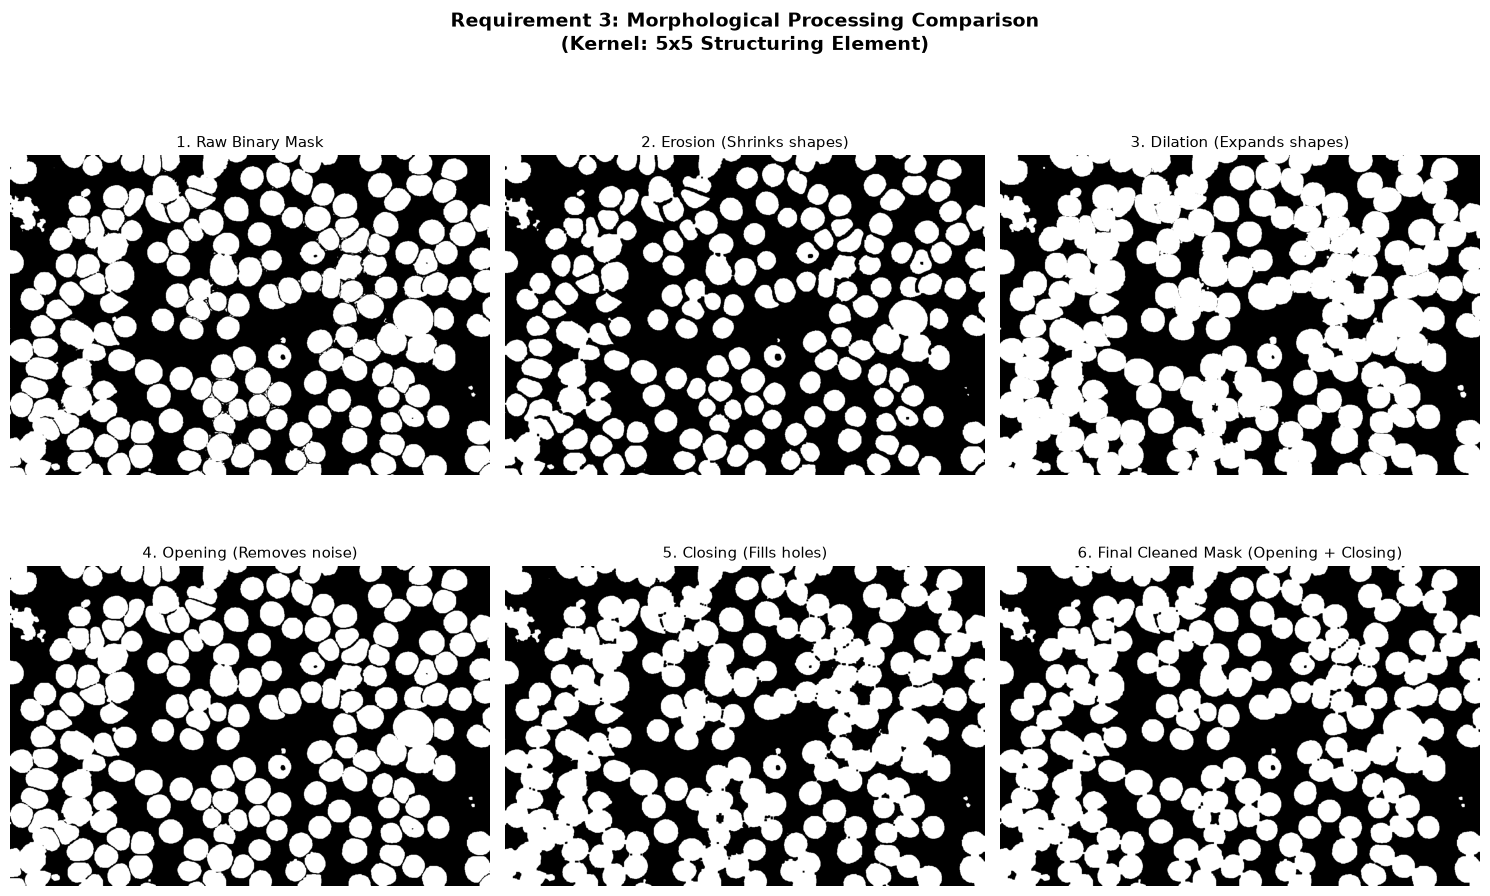

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# CONFIGURATION PARAMETERS (Configurable & Isolated)
# ==========================================================
IMAGE_PATH = r"D:\Ali Garrab\day_2\input\bloodcells.jpeg"

# Configurable morphological parameters
MORPH_CONFIG = {
    "kernel_size": 5,  # Structuring element size (e.g., 5x5)
    "kernel_shape": cv2.MORPH_RECT,  # Options: MORPH_RECT, MORPH_ELLIPSE, MORPH_CROSS
    "iterations": 1,  # Number of iterations
}

HSV_CONFIG = {
    "lower_bound": (0, 30, 30),
    "upper_bound": (180, 255, 255),
}


# ==========================================================
# MORPHOLOGICAL PROCESSING FUNCTIONS
# ==========================================================
def apply_morphology(mask, kernel_size=5, shape=cv2.MORPH_RECT):
    """Applies Erosion, Dilation, Opening, Closing, and outputs

    individual results alongside a fully cleaned mask.
    """
    # Ensure kernel size is odd
    if kernel_size % 2 == 0:
        kernel_size += 1

    # 1. Create Structuring Element (Kernel)
    kernel = cv2.getStructuringElement(shape, (kernel_size, kernel_size))

    # 2. Individual Morphological Operations
    eroded = cv2.erode(mask, kernel, iterations=MORPH_CONFIG["iterations"])
    dilated = cv2.dilate(mask, kernel, iterations=MORPH_CONFIG["iterations"])

    # Opening: Erosion followed by Dilation (Removes small background noise)
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Closing: Dilation followed by Erosion (Fills small holes inside objects)
    closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Combined Sequential Processing: Opening (remove noise) -> Closing (fill holes)
    cleaned_mask = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    return {
        "eroded": eroded,
        "dilated": dilated,
        "opened": opened,
        "closed": closed,
        "cleaned": cleaned_mask,
    }


# ==========================================================
# EXECUTION & VISUALIZATION
# ==========================================================
# Load image and build initial raw binary mask
src_image = cv2.imread(IMAGE_PATH)

if src_image is None:
    raise FileNotFoundError(f"Error: Could not load image from '{IMAGE_PATH}'")

hsv_image = cv2.cvtColor(src_image, cv2.COLOR_BGR2HSV)
raw_mask = cv2.inRange(
    hsv_image,
    np.array(HSV_CONFIG["lower_bound"]),
    np.array(HSV_CONFIG["upper_bound"]),
)

# Process raw mask with morphological operations
morph_results = apply_morphology(
    raw_mask,
    kernel_size=MORPH_CONFIG["kernel_size"],
    shape=MORPH_CONFIG["kernel_shape"],
)

# Save the final cleaned mask to output directory
cv2.imwrite(r"D:\Ali Garrab\day_2\output\mask.jpg", morph_results["cleaned"])

# Display 2x3 comparison grid
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(raw_mask, cmap="gray")
plt.title("1. Raw Binary Mask", fontsize=11)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(morph_results["eroded"], cmap="gray")
plt.title("2. Erosion (Shrinks shapes)", fontsize=11)
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(morph_results["dilated"], cmap="gray")
plt.title("3. Dilation (Expands shapes)", fontsize=11)
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(morph_results["opened"], cmap="gray")
plt.title("4. Opening (Removes noise)", fontsize=11)
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(morph_results["closed"], cmap="gray")
plt.title("5. Closing (Fills holes)", fontsize=11)
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(morph_results["cleaned"], cmap="gray")
plt.title("6. Final Cleaned Mask (Opening + Closing)", fontsize=11)
plt.axis("off")

plt.suptitle(
    f"Requirement 3: Morphological Processing Comparison\n(Kernel: {MORPH_CONFIG['kernel_size']}x{MORPH_CONFIG['kernel_size']} Structuring Element)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

--- Detection Results ---
Total Objects Identified: 5
Object #1: Area = 11874.5 px² | Bounding Box = [X: 201, Y: 316, W: 175, H: 88]
Object #2: Area = 11565.5 px² | Bounding Box = [X: 416, Y: 259, W: 137, H: 120]
Object #3: Area = 7957.0 px² | Bounding Box = [X: 34, Y: 241, W: 107, H: 99]
Object #4: Area = 6147.5 px² | Bounding Box = [X: 132, Y: 111, W: 126, H: 91]
Object #5: Area = 14182.5 px² | Bounding Box = [X: 362, Y: 90, W: 148, H: 99]


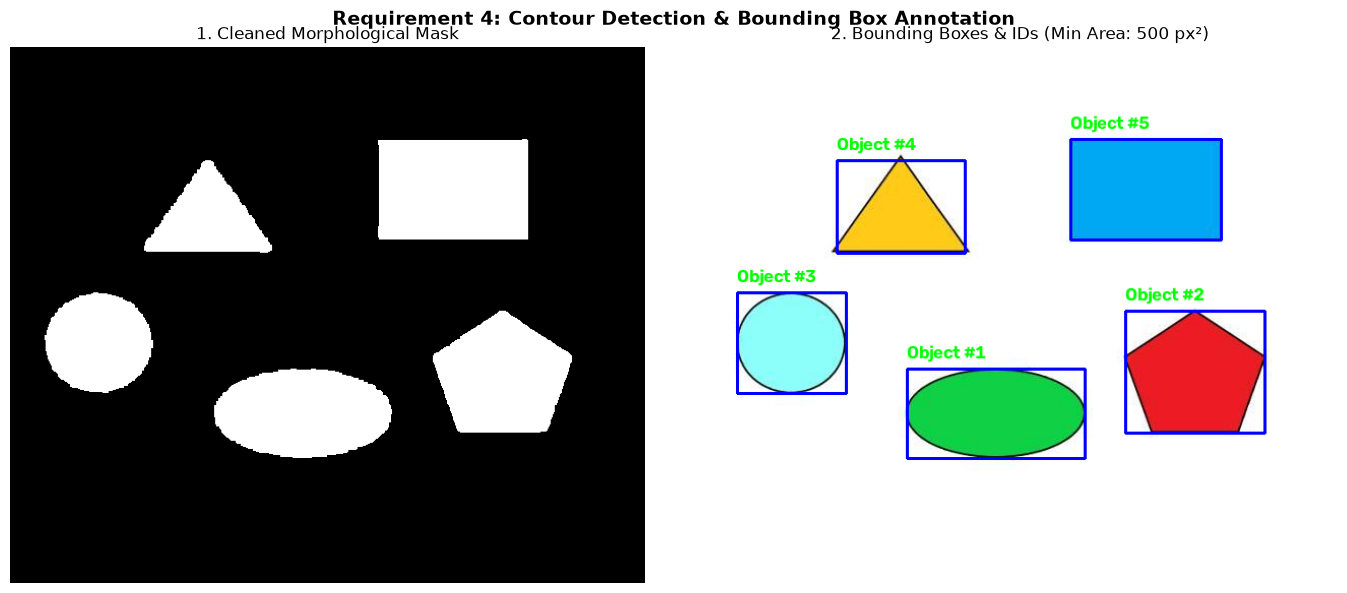

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# CONFIGURATION PARAMETERS (Configurable & Isolated)
# ==========================================================
IMAGE_PATH = r"D:\Ali Garrab\day_2\input\objects.jpg"

# Configurable detection parameters
DETECTION_CONFIG = {
    "min_object_area": 500,  # Minimum pixel area threshold to filter noise
    "box_color": (255, 0, 0),  # Blue bounding box in BGR
    "text_color": (0, 255, 0),  # Green text label in BGR
    "box_thickness": 2,
}

HSV_CONFIG = {
    "lower_bound": (0, 30, 30),
    "upper_bound": (180, 255, 255),
}


# ==========================================================
# OBJECT DETECTION FUNCTION
# ==========================================================
def detect_objects(image, mask, min_area=500):
    """Detects external contours, filters out small noise regions based on min_area,

    assigns unique IDs, and draws bounding boxes on the image.
    """
    # 1. Detect external contours
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    annotated_image = image.copy()
    detected_objects = []
    object_id = 1

    # 2. Iterate through contours
    for cnt in contours:
        area = cv2.contourArea(cnt)

        # Ignore very small regions below configured threshold
        if area < min_area:
            continue

        # Get bounding box coordinates
        x, y, w, h = cv2.boundingRect(cnt)

        # 3. Draw bounding box around detected object
        cv2.rectangle(
            annotated_image,
            (x, y),
            (x + w, y + h),
            DETECTION_CONFIG["box_color"],
            DETECTION_CONFIG["box_thickness"],
        )

        # 4. Assign and display Unique ID label
        label = f"Object #{object_id}"
        cv2.putText(
            annotated_image,
            label,
            (x, max(y - 10, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            DETECTION_CONFIG["text_color"],
            2,
        )

        # Save object metadata
        detected_objects.append(
            {
                "id": object_id,
                "contour": cnt,
                "area": area,
                "bbox": (x, y, w, h),
            }
        )

        object_id += 1

    return annotated_image, detected_objects


# ==========================================================
# EXECUTION & VISUALIZATION
# ==========================================================
# 1. Load image and generate binary mask
src_image = cv2.imread(IMAGE_PATH)

if src_image is None:
    raise FileNotFoundError(f"Error: Could not load image from '{IMAGE_PATH}'")

hsv_image = cv2.cvtColor(src_image, cv2.COLOR_BGR2HSV)
raw_mask = cv2.inRange(
    hsv_image,
    np.array(HSV_CONFIG["lower_bound"]),
    np.array(HSV_CONFIG["upper_bound"]),
)

# Apply morphological opening + closing to clean mask
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
cleaned_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)

# 2. Execute Object Detection
annotated_img, objects_list = detect_objects(
    src_image, cleaned_mask, min_area=DETECTION_CONFIG["min_object_area"]
)

print(
    f"--- Detection Results ---\nTotal Objects Identified: {len(objects_list)}"
)
for obj in objects_list:
    x, y, w, h = obj["bbox"]
    print(
        f"Object #{obj['id']}: Area = {obj['area']} px² | Bounding Box = [X: {x}, Y: {y}, W: {w}, H: {h}]"
    )

# 3. Display Results
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cleaned_mask, cmap="gray")
plt.title("1. Cleaned Morphological Mask", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title(
    f"2. Bounding Boxes & IDs (Min Area: {DETECTION_CONFIG['min_object_area']} px²)",
    fontsize=12,
)
plt.axis("off")

plt.suptitle(
    "Requirement 4: Contour Detection & Bounding Box Annotation",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

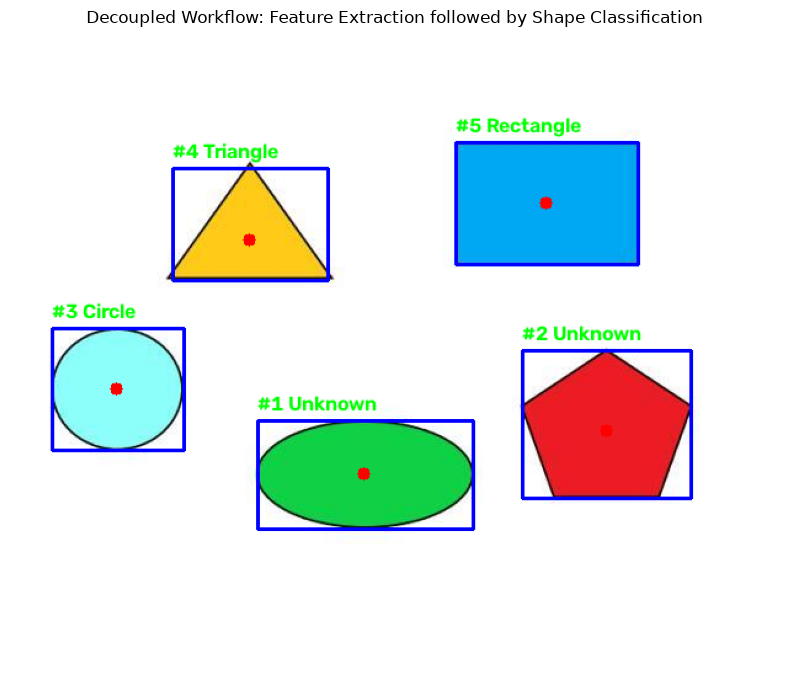

   Object ID  Area (px²)  Perimeter (px)  BBox X  BBox Y  Width  Height  Centroid X  Centroid Y  Aspect Ratio            Color      Shape
0          1     11874.5          463.66     201     316    175      88         287         359          1.99            Green    Unknown
1          2     11565.5          430.92     416     259    137     120         484         324          1.14              Red    Unknown
2          3      7957.0          351.76      34     241    107      99          86         290          1.08             Blue     Circle
3          4      6147.5          377.87     132     111    126      91         194         169          1.38  Orange / Yellow   Triangle
4          5     14182.5          489.07     362      90    148      99         435         139          1.49             Blue  Rectangle


In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# CONFIGURATION PARAMETERS
# ==========================================================
IMAGE_PATH = r"D:\Ali Garrab\day_2\input\objects.jpg"

CONFIG = {
    "min_object_area": 500,
    "poly_epsilon": 0.03,  # Precision factor for polygon approximation
    "hsv_lower": (0, 30, 30),
    "hsv_upper": (180, 255, 255),
}

# ==========================================================
# PREPROCESSING & MASK GENERATION
# ==========================================================
src_image = cv2.imread(IMAGE_PATH)
if src_image is None:
    raise FileNotFoundError(f"Error: Could not load image from '{IMAGE_PATH}'")

hsv_image = cv2.cvtColor(src_image, cv2.COLOR_BGR2HSV)
raw_mask = cv2.inRange(
    hsv_image, np.array(CONFIG["hsv_lower"]), np.array(CONFIG["hsv_upper"])
)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
cleaned_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)


# ==========================================================
# STEP 5: FEATURE EXTRACTION (ISOLATED)
# ==========================================================
def extract_features(image, mask, min_area=500):
    """Extracts required geometric and color metrics for every detected object

    without performing shape classification.
    """
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    features_list = []
    object_id = 1

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        perimeter = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)

        # Centroid calculated strictly from contour moments
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = x + w // 2, y + h // 2

        aspect_ratio = float(w) / h if h != 0 else 0.0

        # Dominant color extraction
        obj_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        cv2.drawContours(obj_mask, [cnt], -1, 255, -1)
        mean_bgr = cv2.mean(image, mask=obj_mask)[:3]

        mean_pixel = np.uint8([[[mean_bgr[0], mean_bgr[1], mean_bgr[2]]]])
        hsv_pixel = cv2.cvtColor(mean_pixel, cv2.COLOR_BGR2HSV)[0][0]
        hue, sat, val = hsv_pixel[0], hsv_pixel[1], hsv_pixel[2]

        if sat < 40:
            color_label = "White / Gray"
        elif hue < 10 or hue >= 170:
            color_label = "Red"
        elif 10 <= hue < 35:
            color_label = "Orange / Yellow"
        elif 35 <= hue < 85:
            color_label = "Green"
        elif 85 <= hue < 130:
            color_label = "Blue"
        elif 130 <= hue < 170:
            color_label = "Purple"
        else:
            color_label = "Unknown"

        features_list.append(
            {
                "Object ID": object_id,
                "Contour": cnt,
                "Area (px²)": round(area, 2),
                "Perimeter (px)": round(perimeter, 2),
                "BBox X": x,
                "BBox Y": y,
                "Width": w,
                "Height": h,
                "Centroid X": cx,
                "Centroid Y": cy,
                "Aspect Ratio": round(aspect_ratio, 2),
                "Color": color_label,
            }
        )
        object_id += 1

    return features_list


# Run Step 5
extracted_features = extract_features(
    src_image, cleaned_mask, min_area=CONFIG["min_object_area"]
)


# ==========================================================
# STEP 6: SHAPE CLASSIFICATION (INDEPENDENT)
# ==========================================================
def classify_shape(contour, aspect_ratio, area, perimeter):
    """Classifies objects into: Triangle, Rectangle, Square, Circle, or Unknown

    using circularity and polygon approximation.
    """
    if perimeter == 0:
        return "Unknown"

    # Circularity metric: (4 * pi * Area) / (Perimeter^2)
    circularity = (4 * np.pi * area) / (perimeter**2)

    # 1. Circle Check (high circularity + uniform aspect ratio)
    if circularity >= 0.80 and (0.88 <= aspect_ratio <= 1.12):
        return "Circle"

    # 2. Polygon Vertex Approximation
    epsilon = CONFIG["poly_epsilon"] * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    num_vertices = len(approx)

    # 3. Shape Mapping
    if num_vertices == 3:
        return "Triangle"
    elif num_vertices == 4:
        return "Square" if 0.92 <= aspect_ratio <= 1.08 else "Rectangle"
    else:
        return "Unknown"


def run_shape_classification(features_list):
    """Takes extracted feature dictionaries and appends shape classifications."""
    classified_records = []

    for obj in features_list:
        shape_type = classify_shape(
            contour=obj["Contour"],
            aspect_ratio=obj["Aspect Ratio"],
            area=obj["Area (px²)"],
            perimeter=obj["Perimeter (px)"],
        )

        record = obj.copy()
        record["Shape"] = shape_type
        classified_records.append(record)

    return classified_records


# Run Step 6
final_data = run_shape_classification(extracted_features)

# ==========================================================
# VISUALIZATION & OUTPUT
# ==========================================================
annotated_img = src_image.copy()

for obj in final_data:
    x, y, w, h = obj["BBox X"], obj["BBox Y"], obj["Width"], obj["Height"]
    cx, cy = obj["Centroid X"], obj["Centroid Y"]

    cv2.rectangle(annotated_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.circle(annotated_img, (cx, cy), 5, (0, 0, 255), -1)  # Centroid dot
    cv2.putText(
        annotated_img,
        f"#{obj['Object ID']} {obj['Shape']}",
        (x, max(y - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (0, 255, 0),
        2,
    )

# Display Annotated Result
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title(
    "Decoupled Workflow: Feature Extraction followed by Shape Classification",
    fontsize=12,
)
plt.axis("off")
plt.tight_layout()
plt.show()

# Display Final Feature DataFrame (Excluding raw contour array)
df_display = pd.DataFrame(final_data).drop(columns=["Contour"])
display(df_display) if "display" in globals() else print(df_display.to_string())

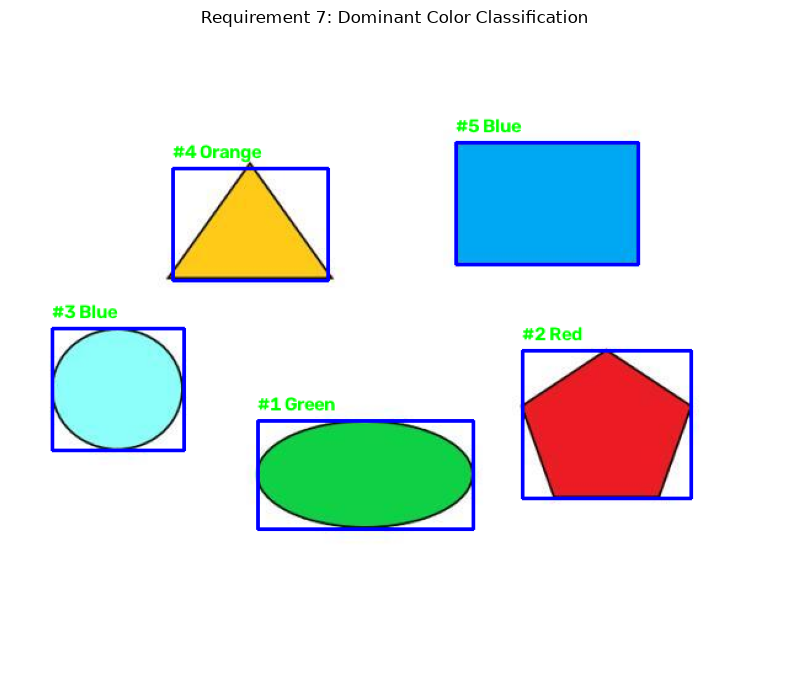

   Object ID Dominant Color         Mean RGB         Mean HSV     BBox (X, Y, W, H)
0          1          Green    (17, 198, 67)   (68, 233, 198)   (201, 316, 175, 88)
1          2            Red    (223, 28, 36)  (179, 223, 223)  (416, 259, 137, 120)
2          3           Blue  (136, 245, 240)   (89, 113, 245)    (34, 241, 107, 99)
3          4         Orange   (237, 189, 27)   (23, 226, 237)   (132, 111, 126, 91)
4          5           Blue    (2, 163, 237)   (99, 253, 237)    (362, 90, 148, 99)


In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# CONFIGURATION PARAMETERS
# ==========================================================
IMAGE_PATH = r"D:\Ali Garrab\day_2\input\objects.jpg"

CONFIG = {
    "min_object_area": 500,
    "hsv_lower": (0, 30, 30),
    "hsv_upper": (180, 255, 255),
    "sat_threshold": 40,  # Minimum saturation to distinguish real color from grayscale
    "val_threshold": 40,  # Minimum value to distinguish real color from dark background
}

# ==========================================================
# COLOR CLASSIFICATION FUNCTION
# ==========================================================
def classify_dominant_color(image_bgr, contour):
    """Calculates the mean color of pixels inside a contour and maps it to a color category using HSV boundaries."""
    # 1. Create a binary mask exclusive to the current object's contour
    mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, -1)

    # 2. Compute the mean BGR values strictly within the masked object area
    mean_bgr = cv2.mean(image_bgr, mask=mask)[:3]
    b, g, r = mean_bgr

    # 3. Convert mean BGR pixel to HSV space
    mean_pixel = np.uint8([[[b, g, r]]])
    hsv_pixel = cv2.cvtColor(mean_pixel, cv2.COLOR_BGR2HSV)[0][0]
    hue, sat, val = hsv_pixel[0], hsv_pixel[1], hsv_pixel[2]

    # 4. Apply Hue-Saturation-Value classification rules
    if sat < CONFIG["sat_threshold"] or val < CONFIG["val_threshold"]:
        color_category = "Other (Gray/White/Black)"
    elif (hue >= 0 and hue < 10) or (hue >= 170 and hue <= 180):
        color_category = "Red"
    elif 10 <= hue < 25:
        color_category = "Orange"
    elif 25 <= hue < 35:
        color_category = "Yellow"
    elif 35 <= hue < 85:
        color_category = "Green"
    elif 85 <= hue < 130:
        color_category = "Blue"
    else:
        color_category = "Other"

    return color_category, (int(r), int(g), int(b)), (int(hue), int(sat), int(val))


# ==========================================================
# PIPELINE EXECUTION
# ==========================================================
# 1. Load image and generate binary mask
src_image = cv2.imread(IMAGE_PATH)
if src_image is None:
    raise FileNotFoundError(f"Error: Could not load image from '{IMAGE_PATH}'")

hsv_image = cv2.cvtColor(src_image, cv2.COLOR_BGR2HSV)
raw_mask = cv2.inRange(
    hsv_image, np.array(CONFIG["hsv_lower"]), np.array(CONFIG["hsv_upper"])
)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
cleaned_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)

# 2. Contour detection
contours, _ = cv2.findContours(
    cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

color_results = []
annotated_img = src_image.copy()
object_id = 1

for cnt in contours:
    if cv2.contourArea(cnt) < CONFIG["min_object_area"]:
        continue

    x, y, w, h = cv2.boundingRect(cnt)

    # Classify color
    color_label, mean_rgb, mean_hsv = classify_dominant_color(src_image, cnt)

    color_results.append(
        {
            "Object ID": object_id,
            "Dominant Color": color_label,
            "Mean RGB": f"({mean_rgb[0]}, {mean_rgb[1]}, {mean_rgb[2]})",
            "Mean HSV": f"({mean_hsv[0]}, {mean_hsv[1]}, {mean_hsv[2]})",
            "BBox (X, Y, W, H)": f"({x}, {y}, {w}, {h})",
        }
    )

    # Annotate image
    cv2.rectangle(annotated_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.putText(
        annotated_img,
        f"#{object_id} {color_label}",
        (x, max(y - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        2,
    )

    object_id += 1

# ==========================================================
# VISUALIZATION & OUTPUT TABLE
# ==========================================================
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title("Requirement 7: Dominant Color Classification", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

df_colors = pd.DataFrame(color_results)
display(df_colors) if "display" in globals() else print(df_colors.to_string())

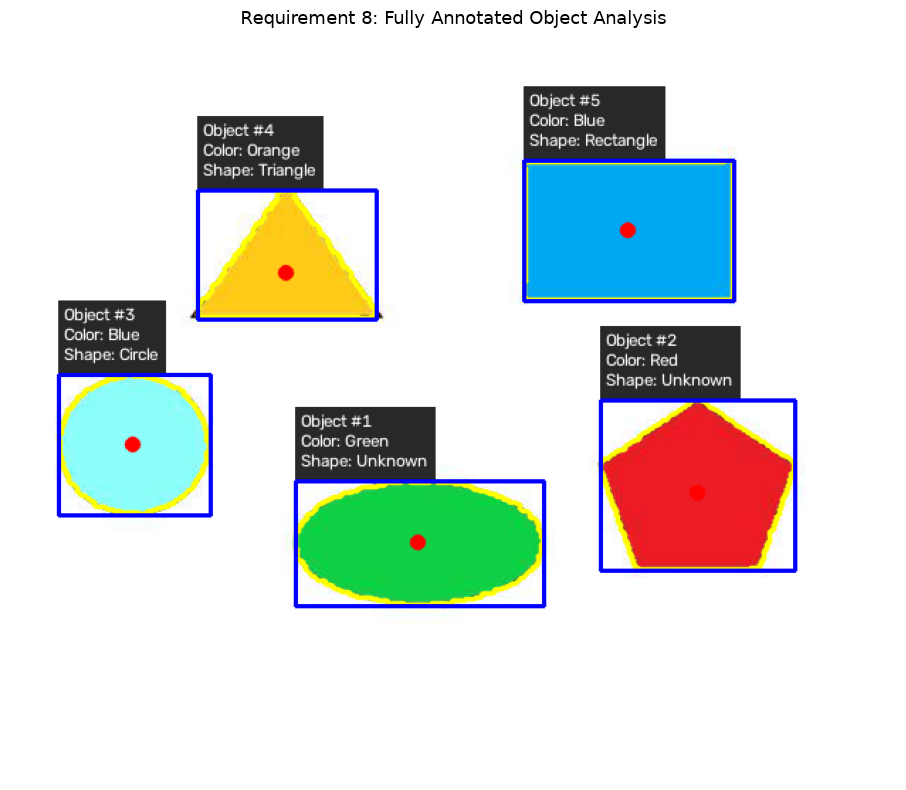

   Object ID   Color      Shape Centroid (X,Y)        BBox (X,Y,W,H)
0          1   Green    Unknown     (287, 359)   (201, 316, 175, 88)
1          2     Red    Unknown     (484, 324)  (416, 259, 137, 120)
2          3    Blue     Circle      (86, 290)    (34, 241, 107, 99)
3          4  Orange   Triangle     (194, 169)   (132, 111, 126, 91)
4          5    Blue  Rectangle     (435, 139)    (362, 90, 148, 99)


In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# CONFIGURATION PARAMETERS (Isolated & Configurable)
# ==========================================================
IMAGE_PATH = r"D:\Ali Garrab\day_2\input\objects.jpg"
OUTPUT_PATH = r"D:\Ali Garrab\day_2\output\annotated_objects.jpg"

CONFIG = {
    "min_object_area": 500,
    "poly_epsilon": 0.03,
    "hsv_lower": (0, 30, 30),
    "hsv_upper": (180, 255, 255),
    # Drawing Colors (BGR format)
    "bbox_color": (255, 0, 0),  # Blue
    "contour_color": (0, 255, 255),  # Yellow
    "centroid_color": (0, 0, 255),  # Red
    "text_color": (255, 255, 255),  # White text on dark bg
    "bg_color": (40, 40, 40),  # Dark background box for text
}


# ==========================================================
# CLASSIFICATION HELPER FUNCTIONS
# ==========================================================
def classify_shape(contour, aspect_ratio, area, perimeter):
    """Classifies contour shape into Triangle, Square, Rectangle, Circle, or Unknown."""
    if perimeter == 0:
        return "Unknown"

    # Circularity metric: (4 * pi * Area) / (Perimeter^2)
    circularity = (4 * np.pi * area) / (perimeter**2)

    if circularity >= 0.80 and (0.88 <= aspect_ratio <= 1.12):
        return "Circle"

    epsilon = CONFIG["poly_epsilon"] * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    num_vertices = len(approx)

    if num_vertices == 3:
        return "Triangle"
    elif num_vertices == 4:
        return "Square" if 0.92 <= aspect_ratio <= 1.08 else "Rectangle"
    else:
        return "Unknown"


def classify_dominant_color(image_bgr, contour):
    """Determines dominant color of contour using HSV mean intensity."""
    mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, -1)

    mean_bgr = cv2.mean(image_bgr, mask=mask)[:3]
    mean_pixel = np.uint8([[[mean_bgr[0], mean_bgr[1], mean_bgr[2]]]])
    hsv_pixel = cv2.cvtColor(mean_pixel, cv2.COLOR_BGR2HSV)[0][0]
    hue, sat, val = hsv_pixel[0], hsv_pixel[1], hsv_pixel[2]

    if sat < 40 or val < 40:
        return "Other"
    elif (hue >= 0 and hue < 10) or (hue >= 170 and hue <= 180):
        return "Red"
    elif 10 <= hue < 25:
        return "Orange"
    elif 25 <= hue < 35:
        return "Yellow"
    elif 35 <= hue < 85:
        return "Green"
    elif 85 <= hue < 130:
        return "Blue"
    else:
        return "Other"


# ==========================================================
# OBJECT ANNOTATION PIPELINE
# ==========================================================
def create_annotated_image(image, min_area=500):
    """Generates fully annotated image with Contours, Bounding Boxes,

    Centroids, and Multi-line Text Labels (ID, Color, Shape).
    """
    # 1. Preprocessing & Morphological Mask Generation
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    raw_mask = cv2.inRange(
        hsv_image, np.array(CONFIG["hsv_lower"]), np.array(CONFIG["hsv_upper"])
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    cleaned_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
    cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)

    # 2. Find contours
    contours, _ = cv2.findContours(
        cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    annotated_img = image.copy()
    object_records = []
    object_id = 1

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        perimeter = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)

        # Centroid calculation strictly via spatial moments
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = x + w // 2, y + h // 2

        aspect_ratio = float(w) / h if h != 0 else 0.0

        # Classifications
        shape_label = classify_shape(cnt, aspect_ratio, area, perimeter)
        color_label = classify_dominant_color(image, cnt)

        # ------------------------------------------------------
        # ANNOTATION DRAWING
        # ------------------------------------------------------
        # 1. Draw Object Contour (Yellow)
        cv2.drawContours(
            annotated_img, [cnt], -1, CONFIG["contour_color"], 2, cv2.LINE_AA
        )

        # 2. Draw Bounding Box (Blue)
        cv2.rectangle(
            annotated_img, (x, y), (x + w, y + h), CONFIG["bbox_color"], 2
        )

        # 3. Draw Centroid Point (Red filled circle)
        cv2.circle(
            annotated_img, (cx, cy), 5, CONFIG["centroid_color"], -1, cv2.LINE_AA
        )

        # 4. Multi-line Text Label Box
        labels = [
            f"Object #{object_id}",
            f"Color: {color_label}",
            f"Shape: {shape_label}",
        ]

        # Calculate positioning for text box
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.42
        thickness = 1
        line_height = 14
        pad = 4

        # Compute label background rectangle dimensions
        max_txt_w = max(
            [cv2.getTextSize(l, font, font_scale, thickness)[0][0] for l in labels]
        )
        box_h = len(labels) * line_height + pad * 2

        # Position box above BBox if space permits, otherwise place inside
        start_y = y - box_h - 2 if y - box_h > 0 else y + 2
        start_x = x

        # Draw semi-transparent background card for readable text
        cv2.rectangle(
            annotated_img,
            (start_x, start_y),
            (start_x + max_txt_w + pad * 2, start_y + box_h),
            CONFIG["bg_color"],
            -1,
        )

        # Render each text line
        text_y = start_y + line_height
        for line in labels:
            cv2.putText(
                annotated_img,
                line,
                (start_x + pad, text_y),
                font,
                font_scale,
                CONFIG["text_color"],
                thickness,
                cv2.LINE_AA,
            )
            text_y += line_height

        object_records.append(
            {
                "Object ID": object_id,
                "Color": color_label,
                "Shape": shape_label,
                "Centroid (X,Y)": (cx, cy),
                "BBox (X,Y,W,H)": (x, y, w, h),
            }
        )

        object_id += 1

    return annotated_img, pd.DataFrame(object_records)


# ==========================================================
# EXECUTION & DISPLAY
# ==========================================================
src_image = cv2.imread(IMAGE_PATH)
if src_image is None:
    raise FileNotFoundError(f"Error: Could not load image from '{IMAGE_PATH}'")

# Generate annotated output
annotated_result, df_summary = create_annotated_image(
    src_image, min_area=CONFIG["min_object_area"]
)

# Save result to file
cv2.imwrite(OUTPUT_PATH, annotated_result)

# Display result inline
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_result, cv2.COLOR_BGR2RGB))
plt.title("Requirement 8: Fully Annotated Object Analysis", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

# Display Summary Table
display(df_summary) if "display" in globals() else print(df_summary.to_string())